# Data augmentation and transfer learning

This notebook aims at training, validating and testing deep neural networks using data augmentation and transfer learning techniques. The notebook includes:
- Build a CNN architecture of MobileNetV2 with the use of the following two techniques:
    - Data augmentation
    - Transfer learning freeze all layers of the base model, un-freeze some layers of the base model
- Train and validate the model to perform the image classification task; Evaluate the performance of the model on the test set.  
- Visualize the model behaviour during the training and the validation.

The dataset is tf_flowers (https://www.tensorflow.org/datasets/catalog/tf_flowers) consists of 3,670 files belonging to 5 classes:
* daisy
* dandelion
* roses
* sunflowers
* tulips

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D

In [ ]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

!pip install tensorflow_datasets

# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras import Model

In [ ]:
#Load the tf_flowers dataset and split training/validation/test set.
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers', # Name of the dataset to load.
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], # Split to training, validation and test set.
    with_info=True, # Return the dataset information and keep in 'metadata' variable.
    as_supervised=True,  # boolean, if True, the returned tf.data.Dataset will have a 2-tuple structure (input, label)
)

# Show the data information (metadata)
print("Metadata: " +str(metadata))

# Show the number of classes of the dataset
num_classes = metadata.features['label'].num_classes
print("Number of classes: " + str(num_classes))

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Metadata: tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/root/tensorflow_datasets/tf_flowers/incomplete.1GFJLM_3.0.1/',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorfl

Image shape: (333, 500, 3)
(1, 333, 500, 3) tf.Tensor([2], shape=(1,), dtype=int64) tulips
(1, 212, 320, 3) tf.Tensor([3], shape=(1,), dtype=int64) sunflowers
(1, 240, 320, 3) tf.Tensor([3], shape=(1,), dtype=int64) sunflowers
(1, 240, 320, 3) tf.Tensor([4], shape=(1,), dtype=int64) roses
(1, 317, 500, 3) tf.Tensor([3], shape=(1,), dtype=int64) sunflowers


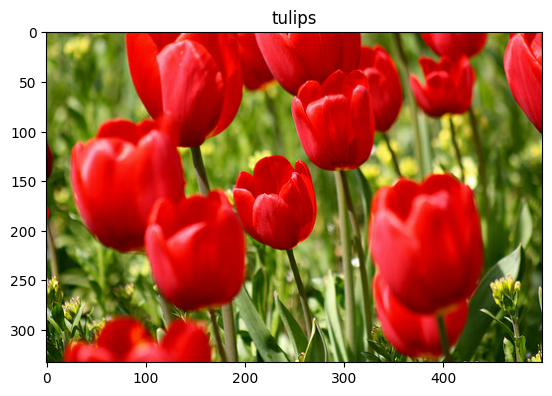

In [ ]:
# Show a data sample from the dataset
get_label_name = metadata.features['label'].int2str # Return the function mapping integer label to string label

# Get the first data sample in the training set
image, label = next(iter(train_ds))
plt.imshow(image) # Plot the image.
plt.title(get_label_name(label)) # Add the flower name to the plot.
print("Image shape: " + str(image.shape))

# Print some of image tensors
count = 0
for image, label in train_ds.batch(batch_size=1):
  if (count < 5):
    print(image.shape, label, get_label_name(label[0])) # Show image tensor information. See that the image tensors vary in size.
    count = count + 1

## 1. Coding tasks

##Data Normalization and Augmentation

In [ ]:
# Data processing with resizing and resclaing
IMG_SIZE = 224
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(IMG_SIZE, IMG_SIZE), # Resize the image to a fixed size
  tf.keras.layers.Rescaling(1./255) # Normalize pixel values
])

In [ ]:
# Data augmentation with Random Flip and Random Rotation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"), # Random flip
  tf.keras.layers.RandomRotation(0.2), # Random rotation with angle
  tf.keras.layers.RandomZoom(0.2), # Random zoom
  tf.keras.layers.RandomContrast(0.2), # Random contrast
])

In [ ]:
# Prepare the data: resize and scale, then augment.
def prepare(ds, shuffle=False, augment=False):

  ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
              num_parallel_calls=tf.data.AUTOTUNE) # Number data samples to process asynchronously in parallel at a time.
  # for image, label in ds.take(1):  # Take a batch from the dataset
  #   print("Pixel value range:", tf.reduce_min(image).numpy(), "-", tf.reduce_max(image).numpy())


  # shuffle=False by default (i.e., do not shuffle the dataset 'ds' by default)
  if shuffle:
    ds = ds.shuffle(buffer_size=1000)

  # Get a batch_size of data samples from the dataset 'ds'.
  ds = ds.batch(batch_size=1024)

  # augment=False by default (i.e., do not augment the dataset 'ds' by default).
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)

  # Prepare the data in the buffer.
  # When tf.data.AUTOTUNE is used, the buffer size is dynamically tuned.
  return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# Resize and rescale the training set; shuffle and augment it.
train_ds = prepare(train_ds, shuffle=True, augment=True)

# Resize and rescale the validation set; DO NOT shuffle and augment it.
val_ds = prepare(val_ds)

# Resize and rescale the test set; DO NOT shuffle and augment it.
test_ds = prepare(test_ds)

Image shape:  (224, 224, 3)


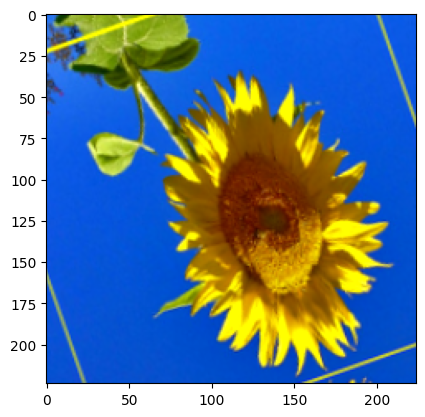

Image shape:  (224, 224, 3)


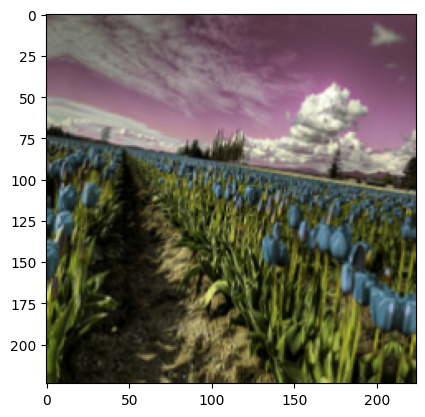

Image shape:  (224, 224, 3)


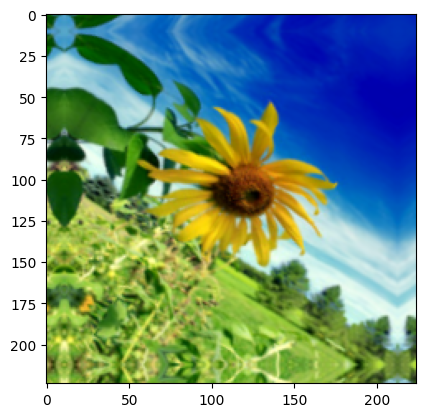

In [ ]:
# Plot some data samples in the training data after processing
count = 0
for image_batch in tfds.as_numpy(train_ds):
  if count < 5:
    print("Image shape: ", image_batch[0][count].shape)
    plt.imshow(image_batch[0][count])
    plt.show()
  count = count + 1

##Freeze all layers of the base model

In [ ]:
base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                               include_top=False,
                                               weights='imagenet')
# Add custom layers to the base model
last_layer = base.output
x = GlobalAveragePooling2D()(last_layer)
x = Dense(128, activation='relu')(x)  # Add a fully connected layer
x = Dropout(0.3)(x)  # Add dropout for regularization
pred = Dense(5, activation='softmax')(x)  # Adjust output layer for 5 classes


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freeze all layer of the model
freeze_model = Model(inputs=base.input, outputs=pred)
base.trainable = False
freeze_model = Model(inputs=base.input, outputs=pred)

In [ ]:
freeze_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the model
freeze_model.compile(optimizer='adam', # Use Adam optimizer
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy']) # Model evaluation metric.

In [ ]:
# Train the model
history_freeze = freeze_model.fit( train_ds,validation_data=val_ds, epochs=10,  batch_size=512)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 224s 48s/step - accuracy: 0.2283 - loss: 2.0639 - val_accuracy: 0.5499 - val_loss: 1.1875
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.5387 - loss: 1.1971 - val_accuracy: 0.6969 - val_loss: 0.8669
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.6507 - loss: 0.9230 - val_accuracy: 0.7441 - val_loss: 0.7076
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7290 - loss: 0.7451 - val_accuracy: 0.7985 - val_loss: 0.6110
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.7502 - loss: 0.6822 - val_accuracy: 0.8131 - val_loss: 0.5542
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.7875 - loss: 0.5903 - val_accuracy: 0.8058 - val_loss: 0.5447
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7891 - loss: 0.5648 - val_accuracy: 0.8149 - val_loss: 0.5060
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.8014 - loss: 0.5345 - val_accuracy: 0.8367 - val_loss: 0.4658
Epoch 

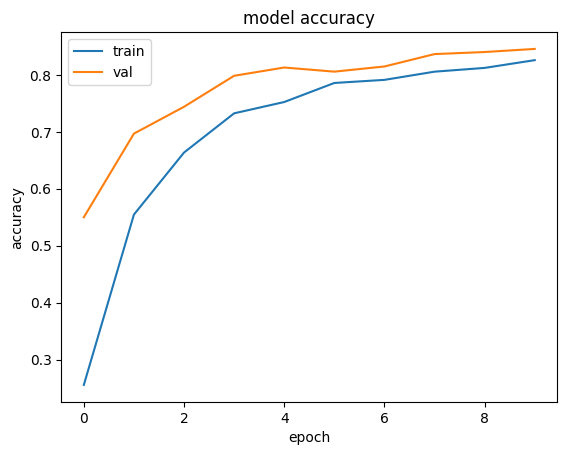

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_freeze.history['accuracy'])
plt.plot(history_freeze.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
freeze_model_eval = freeze_model.evaluate(test_ds)
print("List of metrics" + str(freeze_model.metrics_names))

print("Test loss: " + str(freeze_model_eval[0]))
print("Test accuracy: " + str(freeze_model_eval[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 49s 49s/step - accuracy: 0.8691 - loss: 0.3810
List of metrics['loss', 'compile_metrics']
Test loss: 0.3809581995010376
Test accuracy: 0.8690909147262573


##Unfreeze some layers of the model

Unfreeze top 3 layers of the base model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Extract the last layers
last_layer = base_model.output
x= GlobalAveragePooling2D()(last_layer)
x = Dense(128, activation='relu')(x)  # Add a fully connected layer
x = Dropout(0.3)(x)  # Add dropout for regularization
pred = Dense(5, activation='softmax')(x)  # Adjust output layer for 5 classes

# Show the number of layers in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from layer 150th onwards
fine_tune_at = 150

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
  print("Freeze layer: ", layer.name)
  layer.trainable = False

# Define a new model by grouping layers into an object with training and inference features.
unfreeze_top = Model(inputs=base_model.input, outputs=pred)

# Print model summary. See the changes in the model structure and the number of trainable parameters.
unfreeze_top.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Number of layers in the base model:  154
Freeze layer:  input_layer_2
Freeze layer:  Conv1
Freeze layer:  bn_Conv1
Freeze layer:  Conv1_relu
Freeze layer:  expanded_conv_depthwise
Freeze layer:  expanded_conv_depthwise_BN
Freeze layer:  expanded_conv_depthwise_relu
Freeze layer:  expanded_conv_project
Freeze layer:  expanded_conv_project_BN
Freeze layer:  block_1_expand
Freeze layer:  block_1_expand_BN
Freeze layer:  block_1_expand_relu
Freeze layer:  block_1_pad
Freeze layer:  block_1_depthwise
Freeze layer:  block_1_depthwise_BN
Freeze layer:  block_1_depthwise_relu
Freeze layer:  block_1_project
Freeze layer:  block_1_project_BN
Freeze layer:  block_2_expand
Freeze layer:  block_2_expand_BN
Freeze layer:  block_2_expand_relu
Freeze layer:  block_2_depthwise
Freeze layer:  block_2_depthwise_BN
Freeze layer:  block_2_depthwise_relu
Freeze layer:  block_2_project
Freeze layer:  block_2_project_BN
Freeze layer:  block_2_add
Freeze layer: 

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 577,413 (2.20 MB)

 Non-trainable params: 1,845,184 (7.04 MB)

In [ ]:
# Compile the model
unfreeze_top.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
# Train the model
history_unfreeze = unfreeze_top.fit( train_ds,  validation_data=val_ds, epochs=10,  batch_size=512)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 218s 47s/step - accuracy: 0.3382 - loss: 1.6287 - val_accuracy: 0.7350 - val_loss: 0.6792
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.7634 - loss: 0.6398 - val_accuracy: 0.7586 - val_loss: 0.6751
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.8219 - loss: 0.4634 - val_accuracy: 0.8185 - val_loss: 0.5504
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.8504 - loss: 0.4077 - val_accuracy: 0.8294 - val_loss: 0.5115
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8699 - loss: 0.3607 - val_accuracy: 0.8530 - val_loss: 0.4820
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.8853 - loss: 0.3239 - val_accuracy: 0.8657 - val_loss: 0.4412
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.8953 - loss: 0.2827 - val_accuracy: 0.8675 - val_loss: 0.4037
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.8927 - loss: 0.2926 - val_accuracy: 0.8693 - val_loss: 0.4099
Epoch 

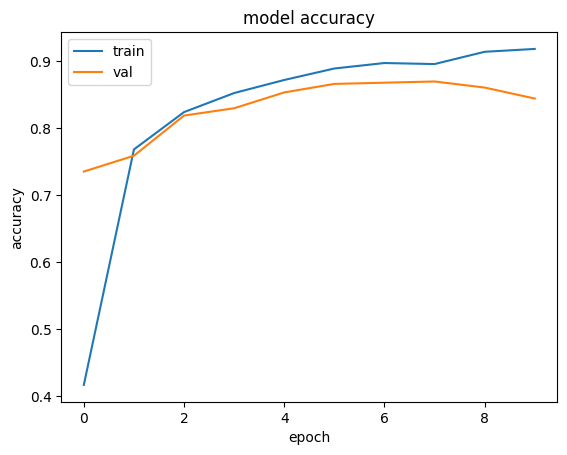

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_unfreeze.history['accuracy'])
plt.plot(history_unfreeze.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
unfreeze_model_eval = unfreeze_top.evaluate(test_ds)
print("List of metrics" + str(unfreeze_top.metrics_names))

print("Test loss: " + str(unfreeze_model_eval[0]))
print("Test accuracy: " + str(unfreeze_model_eval[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 47s 47s/step - accuracy: 0.8600 - loss: 0.4473
List of metrics['loss', 'compile_metrics']
Test loss: 0.4473061263561249
Test accuracy: 0.8600000143051147


Unfreeze top 4 layers of the base model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Extract the last layers
last_layer = base_model.output
x= GlobalAveragePooling2D()(last_layer)
x = Dense(128, activation='relu')(x)  # Add a fully connected layer
x = Dropout(0.3)(x)  # Add dropout for regularization
pred = Dense(5, activation='softmax')(x)  # Adjust output layer for 5 classes

# Show the number of layers in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from layer 151th onwards
fine_tune_at = 151

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
  print("Freeze layer: ", layer.name)
  layer.trainable = False

# Define a new model by grouping layers into an object with training and inference features.
unfreeze_top_1 = Model(inputs=base_model.input, outputs=pred)

# Print model summary. See the changes in the model structure and the number of trainable parameters.
unfreeze_top_1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers in the base model:  154
Freeze layer:  input_layer_2
Freeze layer:  Conv1
Freeze layer:  bn_Conv1
Freeze layer:  Conv1_relu
Freeze layer:  expanded_conv_depthwise
Freeze layer:  expanded_conv_depthwise_BN
Freeze layer:  expanded_conv_depthwise_relu
Freeze layer:  expanded_conv_project
Freeze layer:  expanded_conv_project_BN
Freeze layer:  block_1_expand
Freeze layer:  block_1_expand_BN
Freeze layer:  block_1_expand_relu
Freeze layer:  block_1_pad
Freeze layer:  block_1_depthwise
Freeze layer:  block_1_depthwise_BN
Freeze layer:  block_1_depthwise_relu
Freeze layer:  block_1_project
Freeze layer:  block_1_project_BN
Freeze layer:  block_2_expand
Freeze layer:  block_2_expand_BN
Freeze layer:  block_2_expand_relu
Freeze layer:  block_2_depthwise
Freeze layer:  block_2_depthwise_BN
Freeze layer:  block_2_depthwise_relu
Freeze layer:  block_2_project
Freeze layer:  block_2_project_BN
Freeze layer:  block_2_add
Freeze layer: 

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 576,773 (2.20 MB)

 Non-trainable params: 1,845,824 (7.04 MB)

In [ ]:
# Compile the model
unfreeze_top_1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
# Train the model
history_unfreeze_1 = unfreeze_top_1.fit( train_ds,  validation_data=val_ds, epochs=10,  batch_size=512)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 216s 47s/step - accuracy: 0.3821 - loss: 1.5598 - val_accuracy: 0.7060 - val_loss: 0.7374
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 86s 5s/step - accuracy: 0.7583 - loss: 0.6334 - val_accuracy: 0.7750 - val_loss: 0.5727
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.8298 - loss: 0.4818 - val_accuracy: 0.8040 - val_loss: 0.5322
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.8557 - loss: 0.4137 - val_accuracy: 0.8348 - val_loss: 0.4622
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.8678 - loss: 0.3774 - val_accuracy: 0.8621 - val_loss: 0.4131
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8868 - loss: 0.3327 - val_accuracy: 0.8548 - val_loss: 0.4067
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8962 - loss: 0.3004 - val_accuracy: 0.8621 - val_loss: 0.4259
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.9067 - loss: 0.2712 - val_accuracy: 0.8512 - val_loss: 0.4805
Epoch 

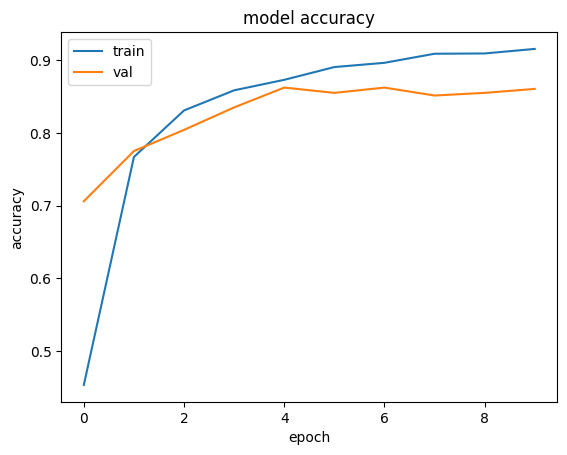

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_unfreeze_1.history['accuracy'])
plt.plot(history_unfreeze_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
unfreeze_eval = unfreeze_top_1.evaluate(test_ds)
print("List of metrics" + str(unfreeze_top_1.metrics_names))

print("Test loss: " + str(unfreeze_eval[0]))
print("Test accuracy: " + str(unfreeze_eval[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 48s 48s/step - accuracy: 0.8836 - loss: 0.4016
List of metrics['loss', 'compile_metrics']
Test loss: 0.40155544877052307
Test accuracy: 0.8836363554000854


## 2. Open discussion questions

### The impact of the chosen data augmentation techniques on training and testing performance

Transfer learning without data augmentation

In [ ]:
train_ds_1 = prepare(train_ds, shuffle=True, augment=False)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Extract the last layers
last_layer = base_model.output
x= GlobalAveragePooling2D()(last_layer)
x = Dense(128, activation='relu')(x)  # Add a fully connected layer
x = Dropout(0.3)(x)  # Add dropout for regularization
pred = Dense(5, activation='softmax')(x)  # Adjust output layer for 5 classes

# Show the number of layers in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from layer 151th onwards
fine_tune_at = 151

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
  print("Freeze layer: ", layer.name)
  layer.trainable = False

# Define a new model by grouping layers into an object with training and inference features.
unfreeze_without_aug = Model(inputs=base_model.input, outputs=pred)

# Print model summary. See the changes in the model structure and the number of trainable parameters.
unfreeze_without_aug.summary()

Number of layers in the base model:  154
Freeze layer:  input_layer_6
Freeze layer:  Conv1
Freeze layer:  bn_Conv1
Freeze layer:  Conv1_relu
Freeze layer:  expanded_conv_depthwise
Freeze layer:  expanded_conv_depthwise_BN
Freeze layer:  expanded_conv_depthwise_relu
Freeze layer:  expanded_conv_project
Freeze layer:  expanded_conv_project_BN
Freeze layer:  block_1_expand
Freeze layer:  block_1_expand_BN
Freeze layer:  block_1_expand_relu
Freeze layer:  block_1_pad
Freeze layer:  block_1_depthwise
Freeze layer:  block_1_depthwise_BN
Freeze layer:  block_1_depthwise_relu
Freeze layer:  block_1_project
Freeze layer:  block_1_project_BN
Freeze layer:  block_2_expand
Freeze layer:  block_2_expand_BN
Freeze layer:  block_2_expand_relu
Freeze layer:  block_2_depthwise
Freeze layer:  block_2_depthwise_BN
Freeze layer:  block_2_depthwise_relu
Freeze layer:  block_2_project
Freeze layer:  block_2_project_BN
Freeze layer:  block_2_add
Freeze layer:  block_3_expand
Freeze layer:  block_3_expand_BN


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 576,773 (2.20 MB)

 Non-trainable params: 1,845,824 (7.04 MB)

In [ ]:
# Compile the model
unfreeze_without_aug.compile(optimizer='adam', # Use Adam optimizer
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy']) # Model evaluation metric.

In [ ]:
# Train the model
history_unfreeze_without_aug = unfreeze_without_aug.fit( train_ds_1,validation_data=val_ds, epochs=10,  batch_size=512)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.3628 - loss: 1.6511 - val_accuracy: 0.8167 - val_loss: 0.5366
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 942ms/step - accuracy: 0.8201 - loss: 0.4991 - val_accuracy: 0.7967 - val_loss: 0.6413
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8629 - loss: 0.3822 - val_accuracy: 0.8312 - val_loss: 0.5360
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 969ms/step - accuracy: 0.9106 - loss: 0.2592 - val_accuracy: 0.8421 - val_loss: 0.4830
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 937ms/step - accuracy: 0.9254 - loss: 0.2148 - val_accuracy: 0.8603 - val_loss: 0.4642
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9492 - loss: 0.1610 - val_accuracy: 0.8494 - val_loss: 0.4785
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9657 - loss: 0.1224 - val_accuracy: 0.8584 - val_loss: 0.4898
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 980ms/step - accuracy: 0.9741 - loss: 0.0983 - val_accuracy: 0.8603 - val_loss: 0.4938
Epo

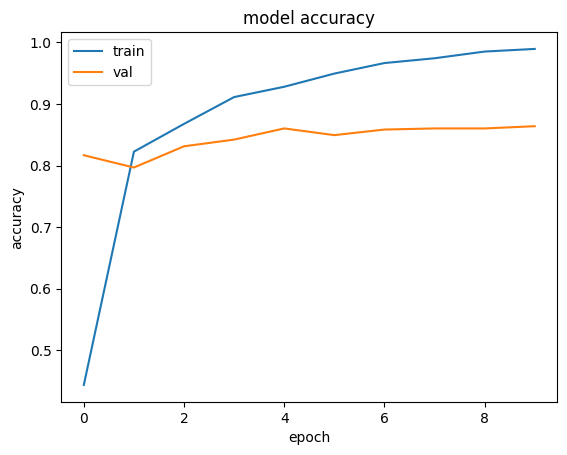

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_unfreeze_without_aug.history['accuracy'])
plt.plot(history_unfreeze_without_aug.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
unfreeze_eval_without_aug = unfreeze_without_aug.evaluate(test_ds)
print("List of metrics" + str(unfreeze_without_aug.metrics_names))

print("Test loss: " + str(unfreeze_eval_without_aug[0]))
print("Test accuracy: " + str(unfreeze_eval_without_aug[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8727 - loss: 0.4900
List of metrics['loss', 'compile_metrics']
Test loss: 0.48996827006340027
Test accuracy: 0.8727272748947144


I evaluated the model performance under two setups:
1. Unfreezing some layers with data augmentation:
 - Data augmentation included RandomFlip, RandomRotation, RandomZoom, and RandomContrast
 - Test accuracy: 88.36%
2. Unfreezing some layers without data augmentation:
 - No augmentation applied to the training data.
 - Test accuracy: 87.27%.

Key observations:
 - With augmentation, training was slower due to increased data variability but resulted in better validation and test performance.
 - Without augmentation, the model learned faster but overfit the training data, as seen in the very high training accuracy ~99% compared to the test accuracy ~87%.
 - Augmentation improved test accuracy by approximately 1.09% (from 87.27% to 88.36%), showing its importance in improving robustness.

Overall, the use of data augmentation, including RandomFlip, RandomRotation, RandomZoom, and RandomContrast, improved the model's ability to generalize to unseen test data. While augmentation slowed down training convergence, it provided significant benefits in terms of regularization and robustness, as evidenced by the higher test accuracy and reduced overfitting.



### Analyze the visualized results, such as accuracy/loss curves or augmented data samples, and connect them to the model’s performance.

From the training and validation accuracy/loss curves:
 - With Data Augmentation:

     - The accuracy improved steadily over the epochs, and the training loss decreased gradually, indicating a stable learning process.
     - However, the gap between training and validation accuracy remained small, suggesting that data augmentation successfully acted as a regularizer, reducing overfitting and improving generalization. This is reflected in the higher test accuracy (~88.36%).

- Without Data Augmentation:

     - The model achieved higher training accuracy earlier but had a larger gap between training and validation accuracy.
     - The validation loss increased in later epochs, further confirming overfitting. This is consistent with the slightly lower test accuracy (~87.27%) compared to the augmented setup.  

Impact of Augmented Data Samples
 - The augmented data samples (e.g., flipped, rotated, and zoomed images) introduced more variety into the training set, simulating real-world variations in flowers' appearances.
 - These transformations allowed the model to learn more generalized features, such as recognizing flowers from different angles, with slight zoom levels, or under varying lighting conditions.
 - As a result, the model trained with data augmentation performed better on the test set, demonstrating improved robustness to unseen variations.